Using device: cuda
✅ Raw checkpoint data loaded.
✅ Hyperparameters fixed.
✅ Model weights loaded successfully!
Generating 1000 samples...
Sampling complete.
Loading real dataset for comparison...


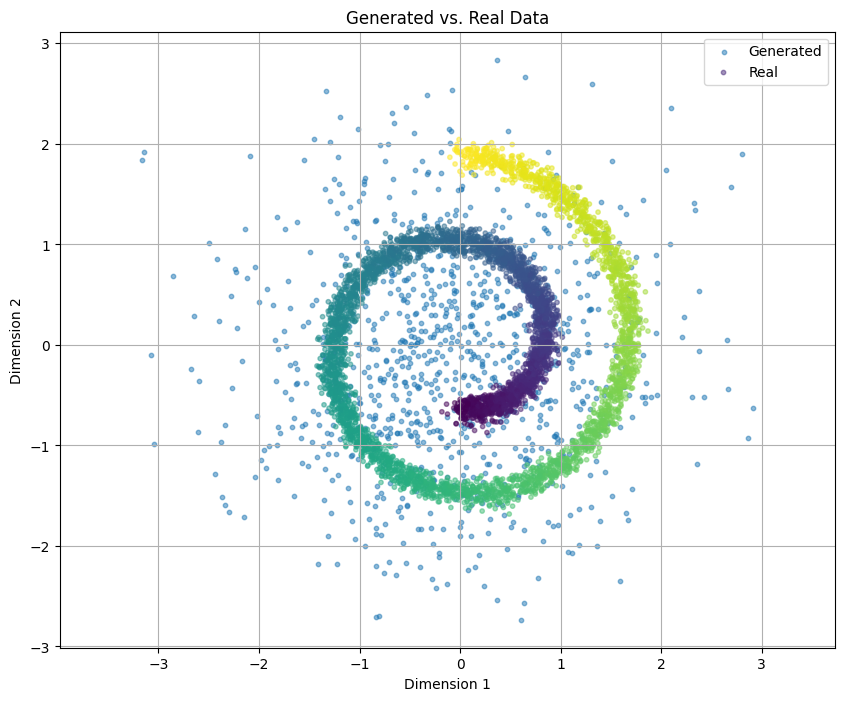

In [ ]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
from train import SDEModel
# --- MODIFICATION: Added import for make_swiss_roll ---
from sklearn.datasets import make_swiss_roll

CHECKPOINT_PATH = "./checkpoints/vp-sde/2025-08-14/14-49-32/checkpoints/epoch=45-train_loss=11.08.ckpt"
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_SAMPLES = 1000
SAMPLING_STEPS = 1000

print(f"Using device: {DEVICE}")

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
print("✅ Raw checkpoint data loaded.")
hparams = checkpoint['hyper_parameters']
cfg = OmegaConf.create(hparams)
cfg.output_dir = "."
print("✅ Hyperparameters fixed.")
model = SDEModel(cfg)
model.load_state_dict(checkpoint['state_dict'])
print("✅ Model weights loaded successfully!")

model.to(DEVICE)
model.eval()
model.setup()

print(f"Generating {N_SAMPLES} samples...")
with torch.no_grad():
    if hasattr(model, 'ema'):
        # Manually load EMA shadow weights if they exist
        ema_key = 'ema.shadow'
        if ema_key in checkpoint:
             model.ema.shadow = checkpoint[ema_key]
        model.ema.apply_shadow()

    samples = model.sde.reverse_sde_sampler(
        model.model,
        (N_SAMPLES, model.cfg.model.input_dim),
        steps=SAMPLING_STEPS
    )
    samples = samples.cpu().numpy()

print("Sampling complete.")

print("Loading real dataset for comparison...")
real_X, real_color = make_swiss_roll(n_samples=cfg.data.n_points, noise=cfg.data.noise)
real_X = real_X[:, [0, 2]] / 7.5
plt.figure(figsize=(10, 8))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5, s=10, label='Generated')
plt.scatter(real_X[:, 0], real_X[:, 1], c=real_color, cmap='viridis', alpha=0.5, s=10, label='Real')

plt.title(f"Generated vs. Real Data")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

In [2]:
# --- Create Test Inputs ---
x_test = torch.randn(3, 2, device=DEVICE) # 3 sample points
t_test = torch.tensor([0.99, 0.5, 0.01], device=DEVICE) # t = high, medium, low noise

# --- Get Model Predictions ---
with torch.no_grad():
    predicted_noise = model.model(x_test, t_test)
    
    # Calculate the L2 norm (magnitude) of each predicted noise vector
    predicted_norms = torch.linalg.norm(predicted_noise, dim=1)

# --- Analyze the Output ---
print("\n--- Diagnostic Results ---")
print(f"Model's Predicted Noise:\n{predicted_noise.cpu().numpy()}")
print(f"\nMagnitude (L2 Norm) of Predicted Noise:\n{predicted_norms.cpu().numpy()}")
print("\n--- Analysis ---")
print("A perfectly trained model should predict noise with a magnitude near sqrt(2) ≈ 1.41 for a 2D problem.")
print(f"The average magnitude of your model's predictions is: {predicted_norms.mean().item():.2f}")


--- Diagnostic Results ---
Model's Predicted Noise:
[[ 0.04778755 -0.05314975]
 [ 0.08977398 -0.04568284]
 [ 0.0856671  -0.04932232]]

Magnitude (L2 Norm) of Predicted Noise:
[0.0714741  0.10072879 0.09885112]

--- Analysis ---
A perfectly trained model should predict noise with a magnitude near sqrt(2) ≈ 1.41 for a 2D problem.
The average magnitude of your model's predictions is: 0.09


Using device: cuda


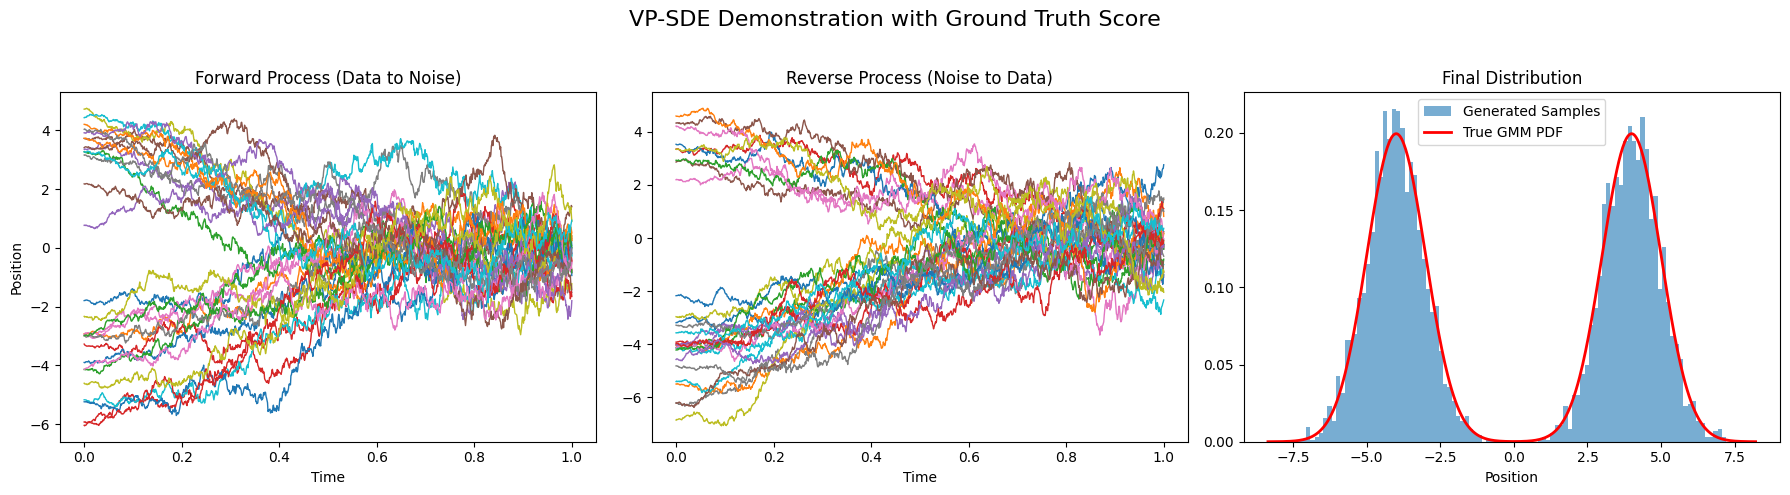

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ===================================================================
# 1. CONFIGURATION AND GMM PARAMETERS
# ===================================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GMM_PARAMS = {
    'weights': torch.tensor([0.5, 0.5], device=DEVICE),
    'means': torch.tensor([-4., 4.], device=DEVICE),
    'stds': torch.tensor([1., 1.], device=DEVICE)
}
print(f"Using device: {DEVICE}")


# ===================================================================
# 2. VP-SDE CLASS DEFINITION
# ===================================================================

class VPSDE:
    """A self-contained VP-SDE class for the diagnostic test."""
    def __init__(self, beta_min=0.1, beta_max=20, N=1000, device='cuda'):
        self.beta_0, self.beta_1, self.N, self.device = beta_min, beta_max, N, device
        self.dt = 1. / N

    def sde(self, x, t):
        """Computes the forward drift and diffusion."""
        beta_t = self.beta_0 + t * (self.beta_1 - self.beta_0)
        drift = -0.5 * beta_t[:, None] * x
        diffusion = torch.sqrt(beta_t)
        return drift, diffusion

    def marginal_prob(self, x_0, t):
        """Computes the mean and std of the perturbation kernel p(x_t|x_0)."""
        log_mean_coeff = -0.25 * t**2 * (self.beta_1 - self.beta_0) - 0.5 * t * self.beta_0
        mean = torch.exp(log_mean_coeff[:, None]) * x_0
        std = torch.sqrt(1.0 - torch.exp(2. * log_mean_coeff))
        return mean, std
        
    def solve_forward_sde(self, x0):
        """Simulates the forward SDE for visualization, returning the full path."""
        xs = [x0]
        x = x0
        for t in np.linspace(0, 1, self.N):
            t_batch = torch.ones(x.shape[0], device=self.device) * t
            drift, diffusion = self.sde(x, t_batch)
            noise = torch.randn_like(x) * torch.sqrt(torch.tensor(self.dt, device=self.device))
            x = x + drift * self.dt + diffusion[:, None] * noise
            xs.append(x)
        return torch.stack(xs, dim=1)

    @torch.no_grad()
    def reverse_sde_sampler(self, score_model, shape, steps):
        """Samples from the reverse SDE and returns the FULL trajectory."""
        x = torch.randn(shape, device=self.device)
        dt = 1. / steps
        trajectory = [x] # Store the initial point at t=1
        
        for t_val in np.linspace(1, 1e-5, steps):
            t = torch.ones(shape[0], device=self.device) * t_val
            drift, diffusion = self.sde(x, t)
            score = score_model(x, t)
            drift = drift - diffusion[:, None]**2 * score
            noise = torch.randn_like(x) * torch.sqrt(torch.tensor(dt, device=self.device))
            x = x - drift * dt + diffusion[:, None] * noise
            trajectory.append(x)
            
        return torch.stack(trajectory, dim=1)


# ===================================================================
# 3. GROUND TRUTH SCORE DEFINITION
# ===================================================================

class GroundTruthScore:
    """A model-like object that computes the analytical score for a GMM."""
    def __init__(self, sde, gmm_params):
        self.sde = sde
        self.gmm_params = gmm_params

    def __call__(self, x, t):
        """Calculates the analytical score for the GMM at time t."""
        x_flat = x.squeeze(-1)
        
        log_mean_coeff = -0.25 * t**2 * (self.sde.beta_1 - self.sde.beta_0) - 0.5 * t * self.sde.beta_0
        alpha_t = torch.exp(2. * log_mean_coeff)

        p_t_x = torch.zeros_like(x_flat)
        grad_p_t_x = torch.zeros_like(x_flat)

        for w, m, s in zip(self.gmm_params['weights'], self.gmm_params['means'], self.gmm_params['stds']):
            mean_t = m * torch.sqrt(alpha_t)
            std_t = torch.sqrt(s**2 * alpha_t + (1 - alpha_t))
            dist = torch.distributions.Normal(mean_t, std_t)
            pdf = torch.exp(dist.log_prob(x_flat))
            grad_log_pdf = -(x_flat - mean_t) / (std_t**2 + 1e-8)
            p_t_x += w * pdf
            grad_p_t_x += w * pdf * grad_log_pdf
        
        return (grad_p_t_x / (p_t_x + 1e-8)).unsqueeze(-1)


# ===================================================================
# 4. HELPER FUNCTIONS AND DEMONSTRATION
# ===================================================================

def get_gmm_samples(n_samples, params):
    """Samples from the GMM distribution."""
    counts = torch.multinomial(params['weights'], n_samples, replacement=True)
    samples = torch.cat([
        torch.randn(int((counts == i).sum()), device=DEVICE) * params['stds'][i] + params['means'][i]
        for i in range(len(params['weights']))
    ])
    return samples[torch.randperm(n_samples)].unsqueeze(-1)

def plot_gmm_dist(samples, params, ax):
    """Plots a histogram of samples against the true GMM PDF."""
    ax.hist(samples, bins=100, density=True, alpha=0.6, label='Generated Samples')
    x_range = torch.linspace(samples.min() - 1, samples.max() + 1, 500, device=DEVICE)
    pdf = torch.zeros_like(x_range)
    for w, m, s in zip(params['weights'], params['means'], params['stds']):
        dist = torch.distributions.Normal(m, s)
        pdf += w * torch.exp(dist.log_prob(x_range))
    ax.plot(x_range.cpu(), pdf.cpu(), 'r-', lw=2, label='True GMM PDF')
    ax.set_title('Final Distribution'); ax.set_xlabel('Position'); ax.legend()

# --- Main Execution ---
n_plot, n_hist, n_steps = 30, 5000, 1000

vpsde = VPSDE(N=n_steps, device=DEVICE)
gt_score_model = GroundTruthScore(vpsde, GMM_PARAMS)

x0_plot = get_gmm_samples(n_plot, GMM_PARAMS)
xT_hist = torch.randn(n_hist, 1, device=DEVICE)

forward_paths = vpsde.solve_forward_sde(x0_plot).cpu().numpy()
reverse_paths = vpsde.reverse_sde_sampler(gt_score_model, (n_hist, 1), n_steps).cpu().numpy()

# Plotting axes must have the same length as the number of trajectory points
ts_forward = np.linspace(0, 1, n_steps + 1)
ts_reverse = np.linspace(1, 0, n_steps + 1) 

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('VP-SDE Demonstration with Ground Truth Score', fontsize=16)

axes[0].plot(ts_forward, forward_paths.squeeze(-1).T, lw=1)
axes[0].set_title('Forward Process (Data to Noise)'); axes[0].set_xlabel('Time'); axes[0].set_ylabel('Position')

axes[1].plot(ts_reverse, reverse_paths[:n_plot].squeeze(-1).T, lw=1)
axes[1].set_title('Reverse Process (Noise to Data)'); axes[1].set_xlabel('Time')

# Use the final point in the trajectory (at t=0) for the distribution plot
plot_gmm_dist(reverse_paths[:, -1, 0], GMM_PARAMS, axes[2])
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

Generating a few sample trajectories...
Plotting results...


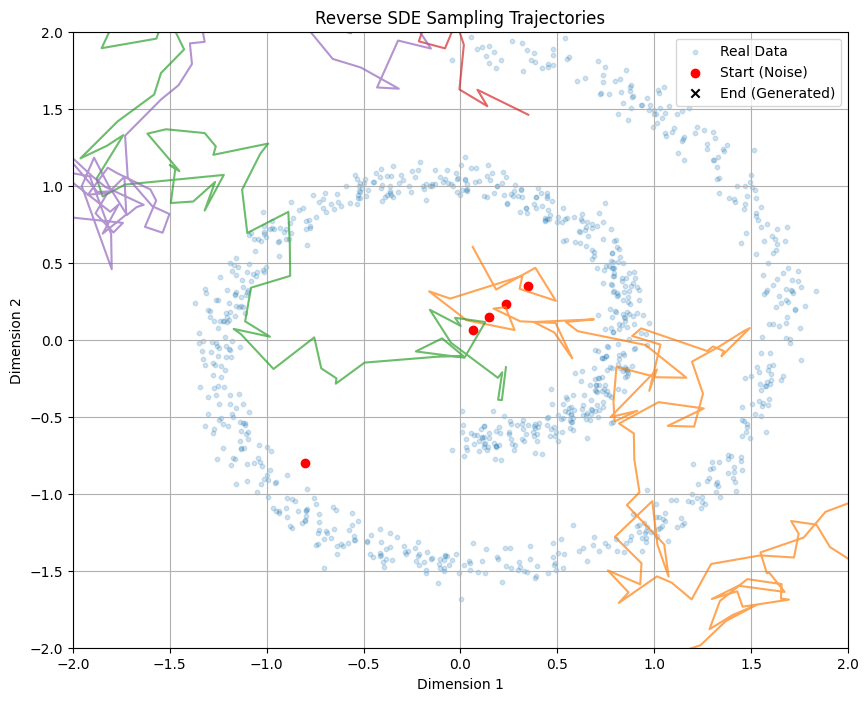

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from train import SDEModel
from sde_lib import VPSDE # We need the SDE class definition
from sklearn.datasets import make_swiss_roll

# --- Modified Sampler to Store Trajectory ---
@torch.no_grad()
def reverse_sde_sampler_with_trajectory(sde, model, shape, steps, device):
    """Sampler that also returns the full trajectory of points."""
    x = torch.randn(shape, device=device)
    dt = 1. / steps
    trajectory = [x.cpu().numpy()] # Store initial point
    
    for t_val in np.linspace(1, 1e-3, steps):
        t = torch.ones(shape[0], device=device) * t_val
        predicted_noise = model(x, t)
        std = sde.marginal_prob(torch.zeros_like(x), t)[1]
        score = -predicted_noise / std
        drift, diffusion = sde.sde(x, t)
        drift = drift - diffusion[:, None]**2 * score
        z = torch.randn_like(x)
        x = x - drift * dt + diffusion[:, None] * torch.sqrt(torch.tensor(dt, device=device)) * z
        trajectory.append(x.cpu().numpy())
    return np.array(trajectory)

# --- Generate Trajectories ---
print("Generating a few sample trajectories...")
trajectories = reverse_sde_sampler_with_trajectory(
    model.sde,
    model.model,
    (5, model.cfg.model.input_dim), # Generate 5 sample paths
    steps=1000,
    device=DEVICE
)

# --- Plot the Trajectories ---
print("Plotting results...")
real_X, _ = make_swiss_roll(n_samples=1000, noise=cfg.data.noise)
real_X = real_X[:, [0, 2]] / 7.5

plt.figure(figsize=(10, 8))
# Plot the real data for scale reference
plt.scatter(real_X[:, 0], real_X[:, 1], alpha=0.2, s=10, label='Real Data')

# Plot the paths
# trajectories shape: (steps+1, num_samples, dims)
for i in range(trajectories.shape[1]):
    plt.plot(trajectories[:, i, 0], trajectories[:, i, 1], alpha=0.7)
    # Mark the start (pure noise) and end points
    plt.scatter(trajectories[0, i, 0], trajectories[0, i, 0], marker='o', color='red', label='Start (Noise)' if i==0 else "")
    plt.scatter(trajectories[-1, i, 0], trajectories[-1, i, 1], marker='x', color='black', label='End (Generated)' if i==0 else "")

plt.title("Reverse SDE Sampling Trajectories")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
# Set axis limits based on real data to see the explosion
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.legend()
plt.show()

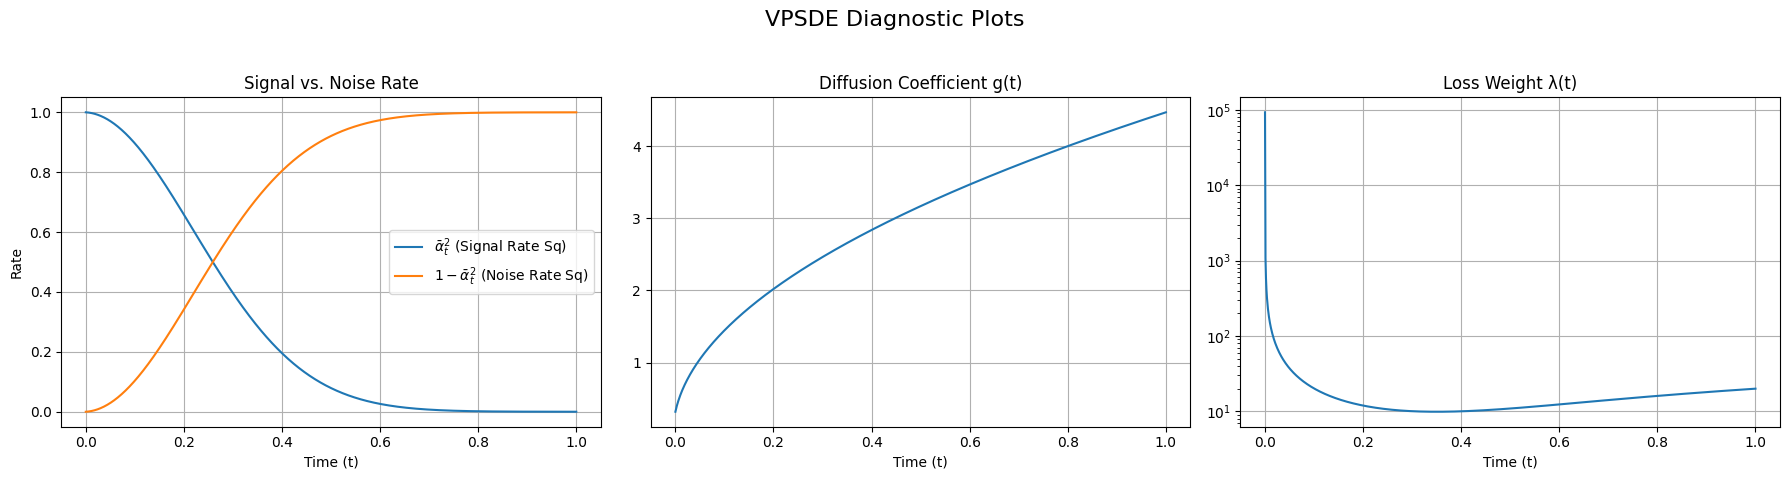

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# You must have your corrected VPSDE class available to import
from sde_lib import VPSDE 

# --- Setup ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
sde = VPSDE(device=DEVICE)
t = torch.linspace(1e-5, 1.0, 1000, device=DEVICE)

# --- Calculations ---
# Get drift and diffusion coefficients
_, g = sde.sde(torch.zeros(1000, 1, device=DEVICE), t)
# Get mean and standard deviation of the perturbation kernel
_, std = sde.marginal_prob(torch.zeros(1000, 1, device=DEVICE), t)
std = std.squeeze()
# Calculate the signal rate (alpha_t_bar)
signal_rate_sq = 1.0 - std**2
# Calculate the loss weight
loss_weight = (g**2) / (std**2 + 1e-8)

# --- Plotting ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("VPSDE Diagnostic Plots", fontsize=16)

# Plot 1: Signal vs. Noise Rate
axs[0].plot(t.cpu(), signal_rate_sq.cpu(), label=r'$\bar{\alpha}_t^2$ (Signal Rate Sq)')
axs[0].plot(t.cpu(), std.cpu()**2, label=r'$1-\bar{\alpha}_t^2$ (Noise Rate Sq)')
axs[0].set_title("Signal vs. Noise Rate")
axs[0].set_xlabel("Time (t)")
axs[0].set_ylabel("Rate")
axs[0].legend()
axs[0].grid(True)

# Plot 2: Diffusion Coefficient g(t)
axs[1].plot(t.cpu(), g.cpu(), label=r'$g(t)$')
axs[1].set_title("Diffusion Coefficient g(t)")
axs[1].set_xlabel("Time (t)")
axs[1].grid(True)

# Plot 3: Loss Weight
axs[2].plot(t.cpu(), loss_weight.cpu(), label=r'$\lambda(t) = g(t)^2 / \sigma(t)^2$')
axs[2].set_title("Loss Weight λ(t)")
axs[2].set_xlabel("Time (t)")
axs[2].set_yscale('log') # Use log scale to see the full range
axs[2].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()